# 04 AlexNet Multi-Class Classification

This notebook trains and evaluates an AlexNet-based model for four-class visual sentiment classification: happiness, anger, sadness, and melancholy.

> **Note:** File paths are written for Google Colab. Update dataset/model paths before running in a new environment.

In [ ]:
from google.colab import drive
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
base_dir   = "/content/drive/MyDrive/MIS 548/Project/sentiment_dataset"
batch_size = 32
num_workers = 0

train_ratio = 0.70
val_ratio   = 0.15
test_ratio  = 0.15

In [ ]:
train_transforms = transforms.Compose([
    transforms.Resize(256),           # resize shortest side to 256
    transforms.CenterCrop(224),       # square crop to 224x224 for AlexNet
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_test_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

In [ ]:
full_dataset = datasets.ImageFolder(root=base_dir, transform=train_transforms)

total      = len(full_dataset)
train_size = int(total * train_ratio)
val_size   = int(total * val_ratio)
test_size  = total - train_size - val_size  # absorbs rounding remainder

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset

# Get all labels from the dataset
labels = [label for _, label in full_dataset.samples]

# First split off train
train_idx, temp_idx = train_test_split(
    range(total), test_size=(val_ratio + test_ratio),
    stratify=labels, random_state=42
)

# Split remaining into val and test
temp_labels = [labels[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx, test_size=test_ratio / (val_ratio + test_ratio),
    stratify=temp_labels, random_state=42
)

train_dataset = Subset(full_dataset, train_idx)
val_dataset   = Subset(full_dataset, val_idx)
test_dataset  = Subset(full_dataset, test_idx)

In [ ]:
val_dataset  = Subset(datasets.ImageFolder(root=base_dir, transform=val_test_transforms), val_idx)
test_dataset = Subset(datasets.ImageFolder(root=base_dir, transform=val_test_transforms), test_idx)

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=num_workers)
val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=num_workers)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=num_workers)

In [ ]:
class_names = full_dataset.classes
print(f"Classes      : {class_names}")
print(f"Total images : {total}")
print(f"Train        : {train_size} ({train_ratio:.0%})")
print(f"Val          : {val_size}   ({val_ratio:.0%})")
print(f"Test         : {test_size}  ({test_ratio:.0%})")

images, labels = next(iter(train_loader))
print(f"\nSample batch — images: {images.shape}, labels: {labels}")
print(f"Label mapping: { {i: c for i, c in enumerate(class_names)} }")

Classes      : ['angry', 'happy', 'melancholic', 'sad']
Total images : 904
Train        : 632 (70%)
Val          : 135   (15%)
Test         : 137  (15%)

Sample batch — images: torch.Size([32, 3, 224, 224]), labels: tensor([2, 0, 0, 1, 2, 1, 3, 2, 0, 3, 2, 3, 2, 3, 3, 2, 0, 0, 0, 2, 1, 2, 3, 3,
        3, 3, 0, 0, 1, 1, 2, 0])
Label mapping: {0: 'angry', 1: 'happy', 2: 'melancholic', 3: 'sad'}


In [ ]:
import torch.nn as nn

class AlexNet(nn.Module):
    def __init__(self, num_classes=4):
        super(AlexNet, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=64, kernel_size=11, stride=4, padding=2),  # [64, 55, 55]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # [64, 27, 27]

            nn.Conv2d(in_channels=64, out_channels=192, kernel_size=5, padding=2),  # [192, 27, 27]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # [192, 13, 13]

            nn.Conv2d(in_channels=192, out_channels=384, kernel_size=3, padding=1),  # [384, 13, 13]
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, padding=1),  # [256, 13, 13]
            nn.ReLU(inplace=True),

            nn.Conv2d(in_channels=256, out_channels=256, kernel_size=3, padding=1),  # [256, 13, 13]
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2),  # [256, 6, 6]
        )

        self.classifier = nn.Sequential(
            nn.Dropout(),
            nn.Linear(in_features=256 * 6 * 6, out_features=4096),
            nn.ReLU(inplace=True),
            nn.Dropout(),
            nn.Linear(in_features=4096, out_features=4096),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=4096, out_features=num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.classifier(x)
        return x

In [ ]:
import torch.optim as optim
from tqdm import tqdm

In [ ]:
PATH       = "/content/drive/MyDrive/alexnet_scratch_best.pth"  # ← update if needed
num_epochs = 30  # increase to 30-50 for a proper training run

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
alexnet = AlexNet(num_classes=4).to(device)

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(alexnet.parameters(), lr=0.01, momentum=0.9, weight_decay=0.0005)

In [ ]:
best_val_acc = 0.0

for epoch in range(num_epochs):

    #Train
    alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = alexnet(inputs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    #Validate
    alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    #Save model with best validation
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(alexnet.state_dict(), PATH)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30:  70%|███████   | 14/20 [04:00<01:43, 17.19s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (100004920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Epoch 1/30: 100%|██████████| 20/20 [05:39<00:00, 16.98s/it]


Epoch [1/30] — Val Accuracy: 26.47%
  → Best model saved (val_acc=26.47%)


Epoch 2/30: 100%|██████████| 20/20 [02:44<00:00,  8.25s/it]


Epoch [2/30] — Val Accuracy: 26.47%


Epoch 3/30: 100%|██████████| 20/20 [02:42<00:00,  8.14s/it]


...

Epoch [28/30] — Val Accuracy: 38.97%


Epoch 29/30: 100%|██████████| 20/20 [02:46<00:00,  8.31s/it]


Epoch [29/30] — Val Accuracy: 40.44%


Epoch 30/30: 100%|██████████| 20/20 [02:46<00:00,  8.32s/it]


Epoch [30/30] — Val Accuracy: 36.76%

Finished Training — Best Val Accuracy: 44.85%


In [ ]:
# Load the best model saved during training
alexnet.load_state_dict(torch.load(PATH))
alexnet.eval()

correct = 0
total   = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = alexnet(inputs)
        _, predicted   = torch.max(outputs.data, 1)
        total         += labels.size(0)
        correct       += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Final Test Accuracy: {test_acc:.2f}%")

In [ ]:
import torchvision.models as models
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm

In [ ]:
PATH_TL    = "/content/drive/MyDrive/alexnet_transfer_best.pth"  # ← update if needed
num_epochs = 30  # increase to 30-50 for a proper training run

In [ ]:
# Load ImageNet pretrained weights
builtin_alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# Step 1 — freeze all layers
for param in builtin_alexnet.parameters():
    param.requires_grad = False

# Step 2 — unfreeze the last conv block (features[10-12])
for param in builtin_alexnet.features[10:].parameters():
    param.requires_grad = True

# Step 3 — replace classifier head for 4 sentiment classes
builtin_alexnet.classifier[6] = nn.Linear(in_features=4096, out_features=4)

# Move to device
builtin_alexnet = builtin_alexnet.to(device)

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 193MB/s]


In [ ]:
criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam([
    {"params": builtin_alexnet.features[10:].parameters(), "lr": 0.0005},
    {"params": builtin_alexnet.classifier.parameters(),    "lr": 0.005},
], weight_decay=0.0005)

Best performing model so far is below:

In [ ]:
best_val_acc = 0.0

for epoch in range(num_epochs):

    # ── TRAINING PHASE ──────────────────────
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_tl.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # ── VALIDATION PHASE ────────────────────
    scheduler = optim.lr_scheduler.StepLR(optimizer_tl, step_size=5, gamma=0.5)
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step()
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    # ── SAVE BEST MODEL ─────────────────────
    patience      = 5   # stop if no improvement for 5 epochs
    no_improve    = 0

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_TL)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30:  30%|███       | 6/20 [01:32<03:30, 15.04s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (100004920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Epoch 1/30: 100%|██████████| 20/20 [05:11<00:00, 15.55s/it]


Epoch [1/30] — Val Accuracy: 48.53%
  → Best model saved (val_acc=48.53%)


Epoch 2/30: 100%|██████████| 20/20 [02:41<00:00,  8.09s/it]


Epoch [2/30] — Val Accuracy: 55.15%
  → Best model saved (val_acc=55.15%)


Epoch 3/30: 100%|██████████| 20/20 [02:42<00:00,  8.11s/it]


...

Epoch [28/30] — Val Accuracy: 63.24%


Epoch 29/30: 100%|██████████| 20/20 [02:42<00:00,  8.12s/it]


Epoch [29/30] — Val Accuracy: 52.94%


Epoch 30/30: 100%|██████████| 20/20 [02:42<00:00,  8.14s/it]


Epoch [30/30] — Val Accuracy: 58.09%

Finished Training — Best Val Accuracy: 63.24%


In [ ]:
scheduler  = optim.lr_scheduler.StepLR(optimizer_tl, step_size=5, gamma=0.5)
best_val_acc = 0.0
patience     = 5
no_improve   = 0

for epoch in range(num_epochs):

    # ── TRAINING PHASE ──────────────────────
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_tl.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # ── VALIDATION PHASE ────────────────────
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step()  # step once per epoch, after validation
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    # ── SAVE BEST MODEL + EARLY STOPPING ────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_TL)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30:  30%|███       | 6/20 [01:37<03:45, 16.14s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (100004920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Epoch 1/30: 100%|██████████| 20/20 [05:25<00:00, 16.29s/it]


Epoch [1/30] — Val Accuracy: 48.53%
  → Best model saved (val_acc=48.53%)


Epoch 2/30: 100%|██████████| 20/20 [02:42<00:00,  8.11s/it]


Epoch [2/30] — Val Accuracy: 55.15%
  → Best model saved (val_acc=55.15%)


Epoch 3/30: 100%|██████████| 20/20 [02:41<00:00,  8.06s/it]


...

Epoch [7/30] — Val Accuracy: 55.15%


Epoch 8/30: 100%|██████████| 20/20 [02:39<00:00,  7.96s/it]


Epoch [8/30] — Val Accuracy: 56.62%


Epoch 9/30: 100%|██████████| 20/20 [02:40<00:00,  8.04s/it]


Epoch [9/30] — Val Accuracy: 55.88%
Early stopping at epoch 9

Finished Training — Best Val Accuracy: 58.09%


In [ ]:
criterion_tl = nn.CrossEntropyLoss()
optimizer_tl = optim.Adam([
    {"params": builtin_alexnet.features[10:].parameters(), "lr": 0.0001},
    {"params": builtin_alexnet.classifier.parameters(),    "lr": 0.001},
], weight_decay=0.0005)

In [ ]:
scheduler = optim.lr_scheduler.StepLR(optimizer_tl, step_size=10, gamma=0.8)
best_val_acc = 0.0
patience     = 10
no_improve   = 0

for epoch in range(num_epochs):

    # ── TRAINING PHASE ──────────────────────
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_tl.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_tl(outputs, labels)
        loss.backward()
        optimizer_tl.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # ── VALIDATION PHASE ────────────────────
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step()  # step once per epoch, after validation
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    # ── SAVE BEST MODEL + EARLY STOPPING ────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_TL)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30: 100%|██████████| 20/20 [02:43<00:00,  8.16s/it]


Epoch [1/30] — Val Accuracy: 56.62%
  → Best model saved (val_acc=56.62%)


Epoch 2/30: 100%|██████████| 20/20 [02:46<00:00,  8.33s/it]


Epoch [2/30] — Val Accuracy: 61.03%
  → Best model saved (val_acc=61.03%)


Epoch 3/30: 100%|██████████| 20/20 [02:49<00:00,  8.49s/it]


...

Epoch [11/30] — Val Accuracy: 58.09%


Epoch 12/30: 100%|██████████| 20/20 [02:47<00:00,  8.37s/it]


Epoch [12/30] — Val Accuracy: 59.56%


Epoch 13/30: 100%|██████████| 20/20 [02:47<00:00,  8.38s/it]


Epoch [13/30] — Val Accuracy: 56.62%
Early stopping at epoch 13

Finished Training — Best Val Accuracy: 61.76%


Feature Extraction Version

In [ ]:
PATH_FE    = "/content/drive/MyDrive/alexnet_feature_extraction_best.pth"
num_epochs = 30

In [ ]:
# Load ImageNet pretrained weights
builtin_alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# Freeze ALL layers — no conv layers will be updated
for param in builtin_alexnet.parameters():
    param.requires_grad = False

# Replace classifier head for 4 sentiment classes
# All other classifier layers keep their pretrained weights
builtin_alexnet.classifier[6] = nn.Linear(in_features=4096, out_features=4)

# Move to device
builtin_alexnet = builtin_alexnet.to(device)

# LOSS + OPTIMIZER

criterion_fe = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(
    builtin_alexnet.classifier[6].parameters(),  # only the new head
    lr=0.001,
    weight_decay=0.0005
)

scheduler = optim.lr_scheduler.StepLR(optimizer_fe, step_size=10, gamma=0.8)

# TRAINING LOOP WITH VALIDATION

best_val_acc = 0.0
patience     = 10
no_improve   = 0

for epoch in range(num_epochs):

    # ── TRAINING PHASE ──────────────────────
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_fe.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_fe(outputs, labels)
        loss.backward()
        optimizer_fe.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # ── VALIDATION PHASE ────────────────────
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step()
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    # ── SAVE BEST MODEL + EARLY STOPPING ────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_FE)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:00<00:00, 489MB/s]
Epoch 1/30:  80%|████████  | 16/20 [06:03<01:32, 23.17s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (100004920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Epoch 1/30: 100%|██████████| 20/20 [07:36<00:00, 22.81s/it]


Epoch [1/30] — Val Accuracy: 56.62%
  → Best model saved (val_acc=56.62%)


Epoch 2/30: 100%|██████████| 20/20 [02:42<00:00,  8.13s/it]


Epoch [2/30] — Val Accuracy: 60.29%
  → Best model saved (val_acc=60.29%)


...

Epoch [10/30] — Val Accuracy: 59.56%


Epoch 11/30: 100%|██████████| 20/20 [02:42<00:00,  8.14s/it]


Epoch [11/30] — Val Accuracy: 55.88%


Epoch 12/30: 100%|██████████| 20/20 [02:42<00:00,  8.12s/it]


Epoch [12/30] — Val Accuracy: 58.09%
Early stopping at epoch 12

Finished Training — Best Val Accuracy: 60.29%


Progressive Unfreezing

In [ ]:
PATH_FE2 = "/content/drive/MyDrive/alexnet_full_classifier_best.pth"
num_epochs = 30

In [ ]:
# Load ImageNet pretrained weights
builtin_alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# Freeze only the conv backbone
for param in builtin_alexnet.features.parameters():
    param.requires_grad = False

# Unfreeze the entire classifier
for param in builtin_alexnet.classifier.parameters():
    param.requires_grad = True

# Replace output layer for 4 classes
builtin_alexnet.classifier[6] = nn.Linear(in_features=4096, out_features=4)

# Move to device
builtin_alexnet = builtin_alexnet.to(device)

# LOSS + OPTIMIZER

criterion_fe = nn.CrossEntropyLoss()
optimizer_fe = optim.Adam(
    builtin_alexnet.classifier.parameters(),
    lr=0.001,
    weight_decay=0.0005
)

scheduler = optim.lr_scheduler.StepLR(optimizer_fe, step_size=10, gamma=0.8)

# TRAINING LOOP WITH VALIDATION

best_val_acc = 0.0
patience     = 10
no_improve   = 0

for epoch in range(num_epochs):

    # ── TRAINING PHASE ──────────────────────
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs}")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_fe.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_fe(outputs, labels)
        loss.backward()
        optimizer_fe.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # ── VALIDATION PHASE ────────────────────
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    scheduler.step()
    print(f"Epoch [{epoch + 1}/{num_epochs}] — Val Accuracy: {val_acc:.2f}%")

    # ── SAVE BEST MODEL + EARLY STOPPING ────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_FE2)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Epoch 1/30:  25%|██▌       | 5/20 [00:42<02:09,  8.62s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (100004920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Epoch 1/30: 100%|██████████| 20/20 [02:45<00:00,  8.27s/it]


Epoch [1/30] — Val Accuracy: 37.50%
  → Best model saved (val_acc=37.50%)


Epoch 2/30: 100%|██████████| 20/20 [02:46<00:00,  8.33s/it]


Epoch [2/30] — Val Accuracy: 48.53%
  → Best model saved (val_acc=48.53%)


Epoch 3/30: 100%|██████████| 20/20 [02:49<00:00,  8.47s/it]


...

Epoch [28/30] — Val Accuracy: 58.09%


Epoch 29/30: 100%|██████████| 20/20 [02:47<00:00,  8.38s/it]


Epoch [29/30] — Val Accuracy: 52.21%


Epoch 30/30: 100%|██████████| 20/20 [02:47<00:00,  8.36s/it]


Epoch [30/30] — Val Accuracy: 56.62%

Finished Training — Best Val Accuracy: 60.29%


Progressive Unfreezing

In [ ]:
PATH_PU    = "/content/drive/MyDrive/alexnet_progressive_unfreezing_best.pth"
num_epochs = 30

# Progressive unfreezing schedule:
# Epochs 1-10:  train classifier[6] only (new head)
# Epochs 11-20: unfreeze features[10:] (last conv block)
# Epochs 21-30: unfreeze features[8:]  (one block deeper)

PHASE_2_EPOCH = 10
PHASE_3_EPOCH = 20

In [ ]:
builtin_alexnet = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

#start fully frozen
for param in builtin_alexnet.parameters():
    param.requires_grad = False

builtin_alexnet.classifier[6] = nn.Linear(in_features=4096, out_features=4)

builtin_alexnet = builtin_alexnet.to(device)

criterion_pu = nn.CrossEntropyLoss()

def get_optimizer(phase):
    if phase == 1:
        # Only train the new head
        return optim.Adam(
            builtin_alexnet.classifier[6].parameters(),
            lr=0.001, weight_decay=0.0005
        )
    elif phase == 2:
        # Train head + last conv block with lower LR for conv
        return optim.Adam([
            {"params": builtin_alexnet.features[10:].parameters(), "lr": 0.0001},
            {"params": builtin_alexnet.classifier[6].parameters(), "lr": 0.001},
        ], weight_decay=0.0005)
    elif phase == 3:
        # Train head + deeper conv block with even lower LR
        return optim.Adam([
            {"params": builtin_alexnet.features[8:].parameters(),  "lr": 0.00001},
            {"params": builtin_alexnet.classifier[6].parameters(), "lr": 0.001},
        ], weight_decay=0.0005)


#TRAINING LOOP WITH PROGRESSIVE UNFREEZING
best_val_acc = 0.0
patience     = 10
no_improve   = 0
current_phase = 1
optimizer_pu  = get_optimizer(phase=1)

for epoch in range(num_epochs):

    # PHASE TRANSITIONS
    if epoch == PHASE_2_EPOCH and current_phase == 1:
        print(f"\n--- Phase 2: Unfreezing features[10:] at epoch {epoch + 1} ---\n")
        for param in builtin_alexnet.features[10:].parameters():
            param.requires_grad = True
        current_phase = 2
        optimizer_pu  = get_optimizer(phase=2)

    elif epoch == PHASE_3_EPOCH and current_phase == 2:
        print(f"\n--- Phase 3: Unfreezing features[8:] at epoch {epoch + 1} ---\n")
        for param in builtin_alexnet.features[8:].parameters():
            param.requires_grad = True
        current_phase = 3
        optimizer_pu  = get_optimizer(phase=3)

    # TRAINING PHASE
    builtin_alexnet.train()
    running_loss = 0.0

    loop = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"Epoch {epoch + 1}/{num_epochs} (Phase {current_phase})")

    for i, (inputs, labels) in loop:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer_pu.zero_grad()
        outputs = builtin_alexnet(inputs)
        loss    = criterion_pu(outputs, labels)
        loss.backward()
        optimizer_pu.step()

        running_loss += loss.item()

        if (i + 1) % 50 == 0:
            avg_loss = running_loss / 50
            loop.set_postfix(loss=avg_loss)
            running_loss = 0.0

    # VALIDATION PHASE
    builtin_alexnet.eval()
    correct = 0
    total   = 0

    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs        = builtin_alexnet(inputs)
            _, predicted   = torch.max(outputs.data, 1)
            total         += labels.size(0)
            correct       += (predicted == labels).sum().item()

    val_acc = 100 * correct / total
    print(f"Epoch [{epoch + 1}/{num_epochs}] (Phase {current_phase}) — Val Accuracy: {val_acc:.2f}%")

    # SAVE BEST MODEL + EARLY STOPPING
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        no_improve   = 0
        torch.save(builtin_alexnet.state_dict(), PATH_PU)
        print(f"  → Best model saved (val_acc={best_val_acc:.2f}%)")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch + 1}")
            break

print(f"\nFinished Training — Best Val Accuracy: {best_val_acc:.2f}%")

Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:00<00:00, 380MB/s]
Epoch 1/30 (Phase 1):  75%|███████▌  | 15/20 [04:48<01:35, 19.17s/it]/usr/local/lib/python3.12/dist-packages/PIL/Image.py:3451: DecompressionBombWarning: Image size (100004920 pixels) exceeds limit of 89478485 pixels, could be decompression bomb DOS attack.
  warnings.warn(
Epoch 1/30 (Phase 1): 100%|██████████| 20/20 [06:19<00:00, 18.99s/it]


Epoch [1/30] (Phase 1) — Val Accuracy: 53.68%
  → Best model saved (val_acc=53.68%)


Epoch 2/30 (Phase 1): 100%|██████████| 20/20 [02:41<00:00,  8.10s/it]


Epoch [2/30] (Phase 1) — Val Accuracy: 57.35%
  → Best model saved (val_acc=57.35%)


...

Epoch [22/30] (Phase 3) — Val Accuracy: 55.88%


Epoch 23/30 (Phase 3): 100%|██████████| 20/20 [02:43<00:00,  8.16s/it]


Epoch [23/30] (Phase 3) — Val Accuracy: 58.82%


Epoch 24/30 (Phase 3): 100%|██████████| 20/20 [02:43<00:00,  8.17s/it]


Epoch [24/30] (Phase 3) — Val Accuracy: 57.35%
Early stopping at epoch 24

Finished Training — Best Val Accuracy: 62.50%


In [ ]:
builtin_alexnet.load_state_dict(torch.load(PATH_TL))
builtin_alexnet.eval()

correct = 0
total   = 0

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = builtin_alexnet(inputs)
        _, predicted   = torch.max(outputs.data, 1)
        total         += labels.size(0)
        correct       += (predicted == labels).sum().item()

test_acc = 100 * correct / total
print(f"Final Test Accuracy (Transfer Learning): {test_acc:.2f}%")

Final Test Accuracy (Transfer Learning): 63.97%


              precision    recall  f1-score   support

       angry       0.60      0.58      0.59        36
       happy       0.69      0.69      0.69        36
 melancholic       0.62      0.75      0.68        28
         sad       0.65      0.56      0.60        36

    accuracy                           0.64       136
   macro avg       0.64      0.65      0.64       136
weighted avg       0.64      0.64      0.64       136



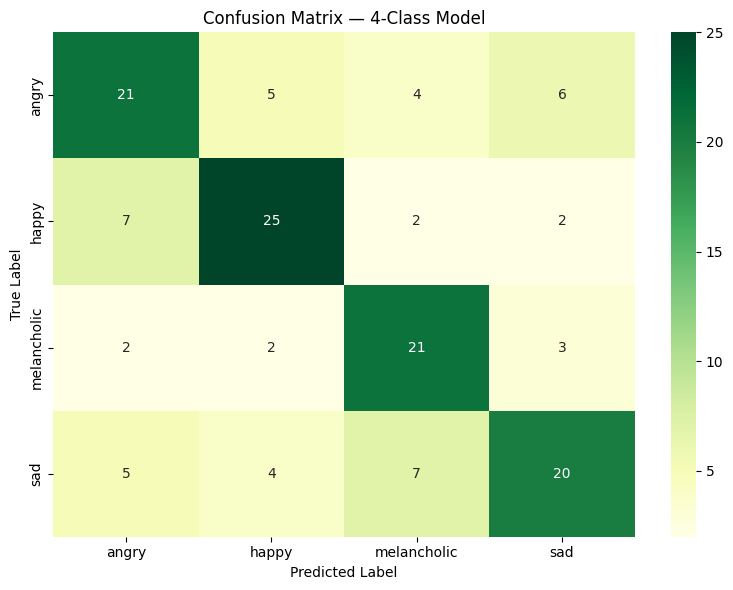

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best 4-class model
builtin_alexnet.load_state_dict(torch.load(PATH_TL))
builtin_alexnet.eval()

all_preds  = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs        = builtin_alexnet(inputs)
        _, predicted   = torch.max(outputs.data, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Classification report
print(classification_report(all_labels, all_preds,
      target_names=["angry", "happy", "melancholic", "sad"]))

# Confusion matrix plot
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="YlGn",
            xticklabels=["angry", "happy", "melancholic", "sad"],
            yticklabels=["angry", "happy", "melancholic", "sad"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — 4-Class Model")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/confusion_matrix_4class.png", dpi=150)
plt.show()